# HFT Market Making Demo

This notebook demonstrates a simple market making strategy using the C++ `hft_core` library.

In [1]:
import sys
sys.path.insert(0, 'build')

import hft_core
import matplotlib.pyplot as plt
import numpy as np

## 1. Market Data Handler

The `MarketDataHandler` tracks the order book - bids (buy orders) and asks (sell orders).

In [2]:
# Create market data handler
market = hft_core.MarketDataHandler()

# Simulate order book with some depth
market.update_bid(100.00, 100)
market.update_ask(100.05, 100)

print(f"Best Bid: {market.get_best_bid()}")
print(f"Best Ask: {market.get_best_ask()}")
print(f"Mid Price: {market.get_mid_price():.4f}")
print(f"Spread: {market.get_spread():.4f}")

Best Bid: 100.0
Best Ask: 100.05
Mid Price: 100.0250
Spread: 0.0500


## 2. Visualize the Spread

Let's visualize the market structure:

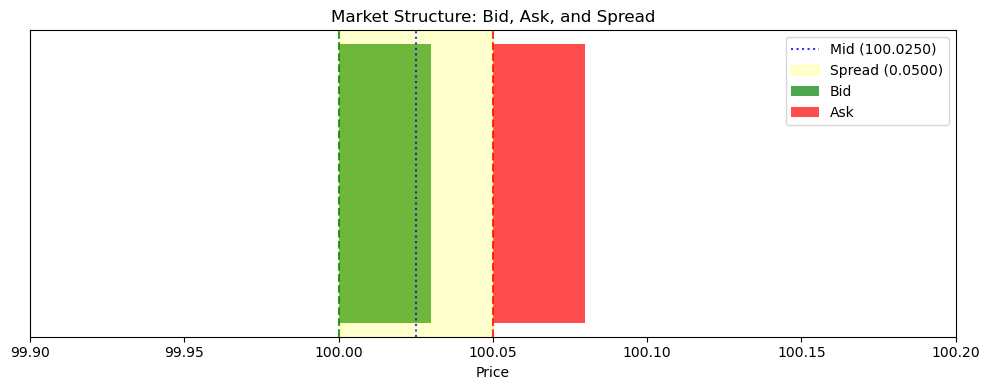

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot bid/ask levels
bid_price = market.get_best_bid()
ask_price = market.get_best_ask()
mid_price = market.get_mid_price()

ax.barh(0, 0.03, left=bid_price, color='green', alpha=0.7, label='Bid')
ax.barh(0, 0.03, left=ask_price, color='red', alpha=0.7, label='Ask')

# Mark key prices
ax.axvline(bid_price, color='green', linestyle='--', alpha=0.8)
ax.axvline(ask_price, color='red', linestyle='--', alpha=0.8)
ax.axvline(mid_price, color='blue', linestyle=':', alpha=0.8, label=f'Mid ({mid_price:.4f})')

# Shade the spread
ax.axvspan(bid_price, ask_price, alpha=0.2, color='yellow', label=f'Spread ({ask_price - bid_price:.4f})')

ax.set_xlim(99.9, 100.2)
ax.set_yticks([])
ax.set_xlabel('Price')
ax.set_title('Market Structure: Bid, Ask, and Spread')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3. Market Maker Quotes

The market maker posts quotes **inside** the spread to compete for order flow.

Key concept:
- `inside_pct=0.0`: quotes at market prices (bid=bid, ask=ask)
- `inside_pct=0.5`: quotes at mid-price (fair value)
- `inside_pct=1.0`: quotes at opposite edges (suicidal!)

In [4]:
# Create market maker with different inside_pct values
mm_aggressive = hft_core.SimpleMarketMaker(0.2, 50)   # 20% inside spread
mm_midpoint = hft_core.SimpleMarketMaker(0.5, 50)    # 50% inside spread
mm_passive = hft_core.SimpleMarketMaker(0.8, 50)      # 80% inside spread

# Generate quotes
buy_a, sell_a = mm_aggressive.generate_quotes(market)
buy_m, sell_m = mm_midpoint.generate_quotes(market)
buy_p, sell_p = mm_passive.generate_quotes(market)

print("Aggressive (20% inside):")
print(f"  Buy:  {buy_a.price:.4f}, Sell: {sell_a.price:.4f}, Profit: {sell_a.price - buy_a.price:.4f}")
print("\nMidpoint (50% inside):")
print(f"  Buy:  {buy_m.price:.4f}, Sell: {sell_m.price:.4f}, Profit: {sell_m.price - buy_m.price:.4f}")
print("\nPassive (80% inside):")
print(f"  Buy:  {buy_p.price:.4f}, Sell: {sell_p.price:.4f}, Profit: {sell_p.price - buy_p.price:.4f}")

Aggressive (20% inside):
  Buy:  100.0050, Sell: 100.0450, Profit: 0.0400

Midpoint (50% inside):
  Buy:  100.0125, Sell: 100.0375, Profit: 0.0250

Passive (80% inside):
  Buy:  100.0200, Sell: 100.0300, Profit: 0.0100


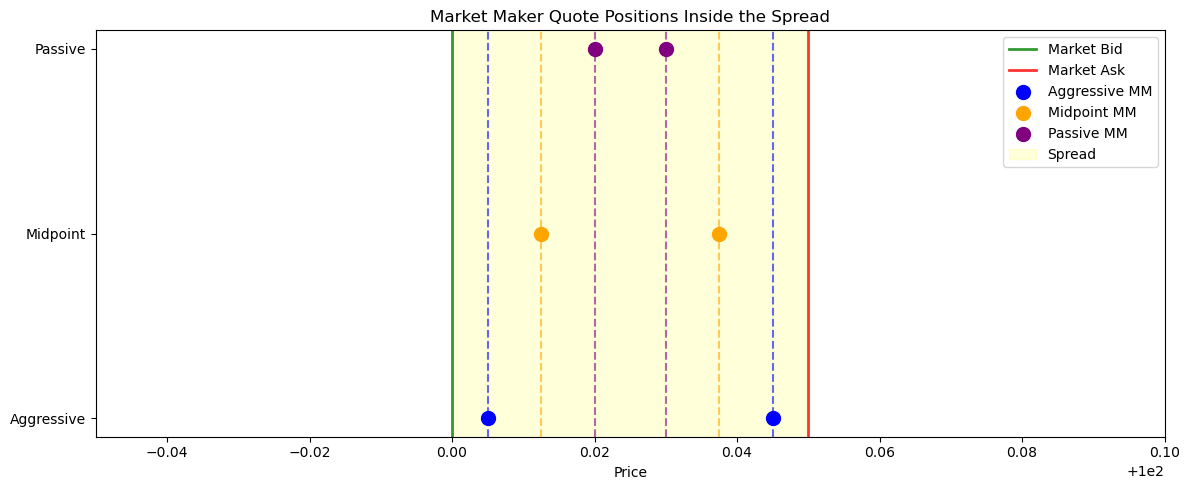

In [5]:
# Visualize different MM quote positions
fig, ax = plt.subplots(figsize=(12, 5))

# Market prices
ax.axvline(bid_price, color='green', linestyle='-', linewidth=2, alpha=0.8, label='Market Bid')
ax.axvline(ask_price, color='red', linestyle='-', linewidth=2, alpha=0.8, label='Market Ask')

# MM quotes
ax.axvline(buy_a.price, color='blue', linestyle='--', alpha=0.6)
ax.axvline(sell_a.price, color='blue', linestyle='--', alpha=0.6)
ax.scatter([buy_a.price, sell_a.price], [0.5, 0.5], color='blue', s=100, zorder=5, label='Aggressive MM')

ax.axvline(buy_m.price, color='orange', linestyle='--', alpha=0.6)
ax.axvline(sell_m.price, color='orange', linestyle='--', alpha=0.6)
ax.scatter([buy_m.price, sell_m.price], [1, 1], color='orange', s=100, zorder=5, label='Midpoint MM')

ax.axvline(buy_p.price, color='purple', linestyle='--', alpha=0.6)
ax.axvline(sell_p.price, color='purple', linestyle='--', alpha=0.6)
ax.scatter([buy_p.price, sell_p.price], [1.5, 1.5], color='purple', s=100, zorder=5, label='Passive MM')

# Shade spread
ax.axvspan(bid_price, ask_price, alpha=0.15, color='yellow', label='Spread')

ax.set_xlim(99.95, 100.1)
ax.set_yticks([0.5, 1, 1.5])
ax.set_yticklabels(['Aggressive', 'Midpoint', 'Passive'])
ax.set_xlabel('Price')
ax.set_title('Market Maker Quote Positions Inside the Spread')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Profit vs Fill Probability Tradeoff

Market makers face a fundamental tradeoff:
- More aggressive (closer to mid): higher profit per trade, lower fill rate
- More passive (closer to edges): lower profit per trade, higher fill rate

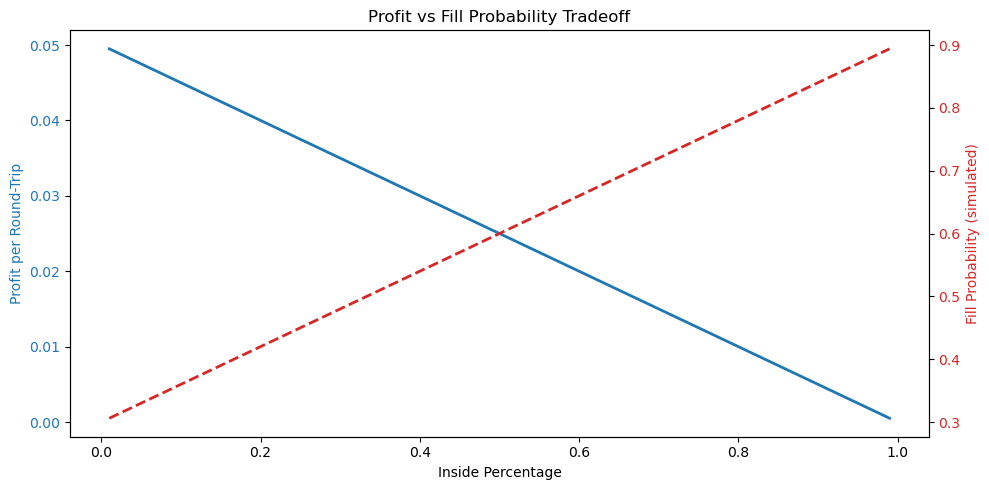

In [6]:
# Simulate profit vs fill probability tradeoff
inside_pcts = np.linspace(0.01, 0.99, 50)
profits = []
fill_probs = []  # Simulated fill probability (higher near edges)

for pct in inside_pcts:
    mm = hft_core.SimpleMarketMaker(pct, 50)
    buy, sell = mm.generate_quotes(market)
    profit = sell.price - buy.price
    profits.append(profit)
    # Simplified fill model: more likely to get filled near edges
    fill_prob = 0.3 + 0.6 * pct
    fill_probs.append(fill_prob)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Profit (blue)
color = 'tab:blue'
ax1.set_xlabel('Inside Percentage')
ax1.set_ylabel('Profit per Round-Trip', color=color)
ax1.plot(inside_pcts, profits, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Fill probability (red, different scale)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Fill Probability (simulated)', color=color)
ax2.plot(inside_pcts, fill_probs, color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_title('Profit vs Fill Probability Tradeoff')
fig.tight_layout()
plt.show()

## 5. Round-Trip Trading Simulation

Let's simulate what happens when a market maker gets filled on both sides:

In [7]:
# Simulate a round-trip trade
mm = hft_core.SimpleMarketMaker(0.3, 100)
buy, sell = mm.generate_quotes(market)

print("=== Round-Trip Trade Simulation ===\n")
print(f"Step 1: Market Maker posts BUY order")
print(f"        Price: ${buy.price:.4f}, Quantity: {buy.quantity} shares")

print(f"\nStep 2: Someone SELLs to MM at ${buy.price:.4f}")
print(f"        MM receives: 100 shares, Cost: ${buy.price * buy.quantity:.2f}")

print(f"\nStep 3: Market Maker posts SELL order")
print(f"        Price: ${sell.price:.4f}, Quantity: {sell.quantity} shares")

print(f"\nStep 4: Someone BUYs from MM at ${sell.price:.4f}")
print(f"        MM receives: ${sell.price * sell.quantity:.2f}")

# Calculate P&L
cost = buy.price * buy.quantity
revenue = sell.price * sell.quantity
pnl = revenue - cost

print("\n" + "=" * 40)
print(f"Total Cost (Buy):      ${cost:.2f}")
print(f"Total Revenue (Sell): ${revenue:.2f}")
print(f"\n>>> PROFIT: ${pnl:.2f} <<<")
print(f">>> Profit per share: ${pnl / buy.quantity:.4f}")

=== Round-Trip Trade Simulation ===

Step 1: Market Maker posts BUY order
        Price: $100.0075, Quantity: 100 shares

Step 2: Someone SELLs to MM at $100.0075
        MM receives: 100 shares, Cost: $10000.75

Step 3: Market Maker posts SELL order
        Price: $100.0425, Quantity: 100 shares

Step 4: Someone BUYs from MM at $100.0425
        MM receives: $10004.25

Total Cost (Buy):      $10000.75
Total Revenue (Sell): $10004.25

>>> PROFIT: $3.50 <<<
>>> Profit per share: $0.0350


## 6. Risk: Price Movement

The market maker faces **inventory risk** - if price moves against held position before completing the round-trip.

In [8]:
# Simulate inventory risk
print("=== Inventory Risk Scenario ===\n")

# MM gets filled on buy side
mm = hft_core.SimpleMarketMaker(0.3, 100)
buy, sell = mm.generate_quotes(market)
print(f"MM bought 100 shares at ${buy.price:.4f}")
print(f"Current ask (to sell): ${sell.price:.4f}")

# Price moves down (adverse selection!)
market.update_ask(100.01, 100)  # Ask dropped
new_mid = market.get_mid_price()

# MM's sell order is now way above market
print(f"\n!!! PRICE MOVED AGAINST MM !!!")
print(f"New market ask: ${market.get_best_ask():.4f}")
print(f"MM's sell quote: ${sell.price:.4f}")
print(f"\nTo sell now, MM must match new ask:")
print(f"  MM would sell at ${market.get_best_ask():.4f}")
print(f"  Loss vs expected: ${(market.get_best_ask() - sell.price) * 100:.2f}")

=== Inventory Risk Scenario ===

MM bought 100 shares at $100.0075
Current ask (to sell): $100.0425

!!! PRICE MOVED AGAINST MM !!!
New market ask: $100.0100
MM's sell quote: $100.0425

To sell now, MM must match new ask:
  MM would sell at $100.0100
  Loss vs expected: $-3.25


---

## Summary

| Concept | Description |
|---------|-------------|
| **Bid/Ask** | Best prices others are willing to buy/sell |
| **Spread** | Difference between ask and bid |
| **Mid Price** | Fair value estimate = (bid + ask) / 2 |
| **Market Maker** | Provides liquidity by always quoting |
| **Inside Spread** | Quoting between bid and ask |
| **Round-Trip** | Buy then sell (or vice versa) |
| **Inventory Risk** | Price moving against held position |